In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV directly from GitHub
url = 'https://raw.githubusercontent.com/freeCodeCamp/boilerplate-page-view-time-series-visualizer/main/fcc-forum-pageviews.csv'
df = pd.read_csv(url, parse_dates=['date'], index_col='date')

# Clean data - remove top 2.5% and bottom 2.5%
lower_quantile = df['value'].quantile(0.025)
upper_quantile = df['value'].quantile(0.975)
df = df[(df['value'] >= lower_quantile) & (df['value'] <= upper_quantile)]

# ----------------- Line Plot -----------------
def draw_line_plot():
    fig, ax = plt.subplots(figsize=(15,5))
    ax.plot(df.index, df['value'], color='red', linewidth=1)
    ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
    ax.set_xlabel('Date')
    ax.set_ylabel('Page Views')
    plt.tight_layout()
    return fig

# ----------------- Bar Plot -----------------
def draw_bar_plot():
    df_bar = df.copy()
    df_bar['year'] = df_bar.index.year
    df_bar['month'] = df_bar.index.month_name()

    df_bar_grouped = df_bar.groupby(['year','month'])['value'].mean().unstack()

    # Order months Jan-Dec
    months_order = ['January','February','March','April','May','June','July','August',
                    'September','October','November','December']
    df_bar_grouped = df_bar_grouped[months_order]

    fig = df_bar_grouped.plot(kind='bar', figsize=(15,7)).figure
    plt.xlabel('Years')
    plt.ylabel('Average Page Views')
    plt.legend(title='Months')
    plt.tight_layout()
    return fig

# ----------------- Box Plot -----------------
def draw_box_plot():
    df_box = df.copy()
    df_box.reset_index(inplace=True)
    df_box['year'] = df_box['date'].dt.year
    df_box['month'] = df_box['date'].dt.strftime('%b')
    df_box['month_num'] = df_box['date'].dt.month
    df_box = df_box.sort_values('month_num')

    fig, axes = plt.subplots(1,2, figsize=(20,6))

    sns.boxplot(x='year', y='value', data=df_box, ax=axes[0])
    axes[0].set_title('Year-wise Box Plot (Trend)')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Page Views')

    sns.boxplot(x='month', y='value', data=df_box, ax=axes[1])
    axes[1].set_title('Month-wise Box Plot (Seasonality)')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Page Views')

    plt.tight_layout()
    return fig

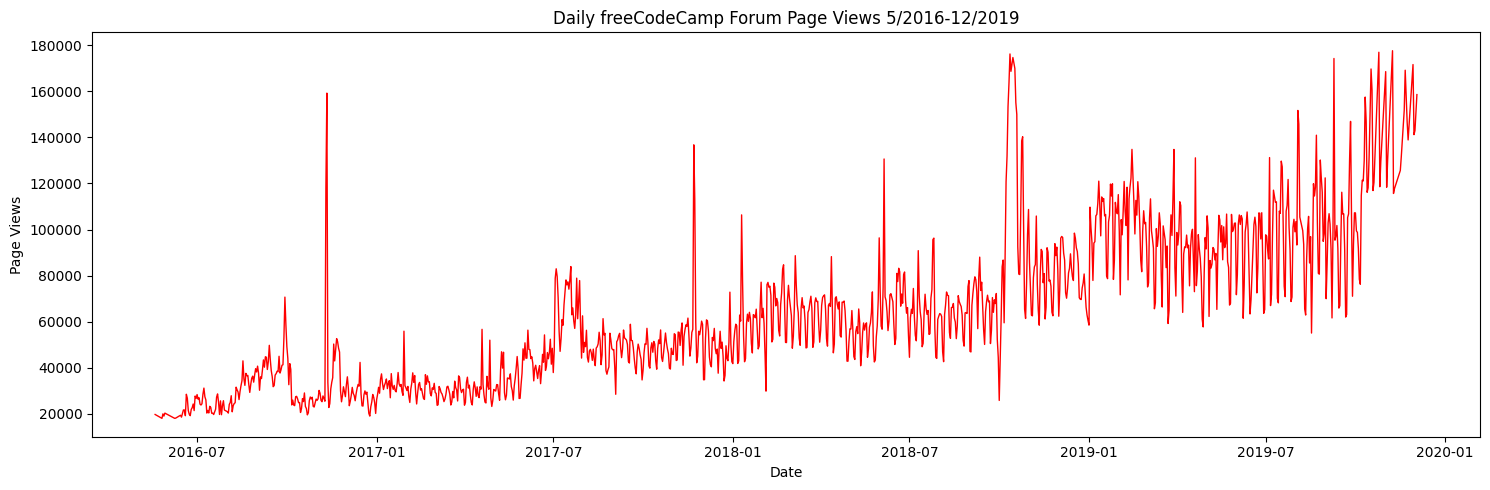

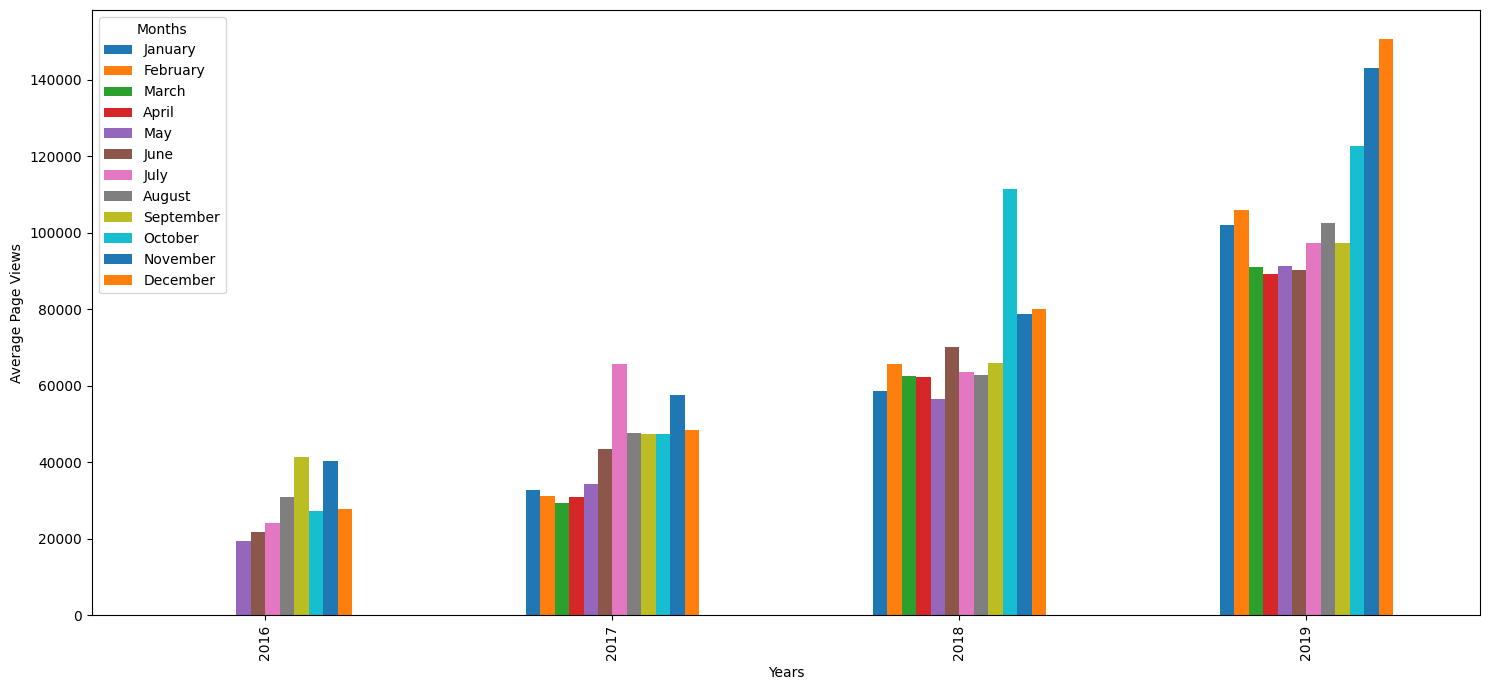

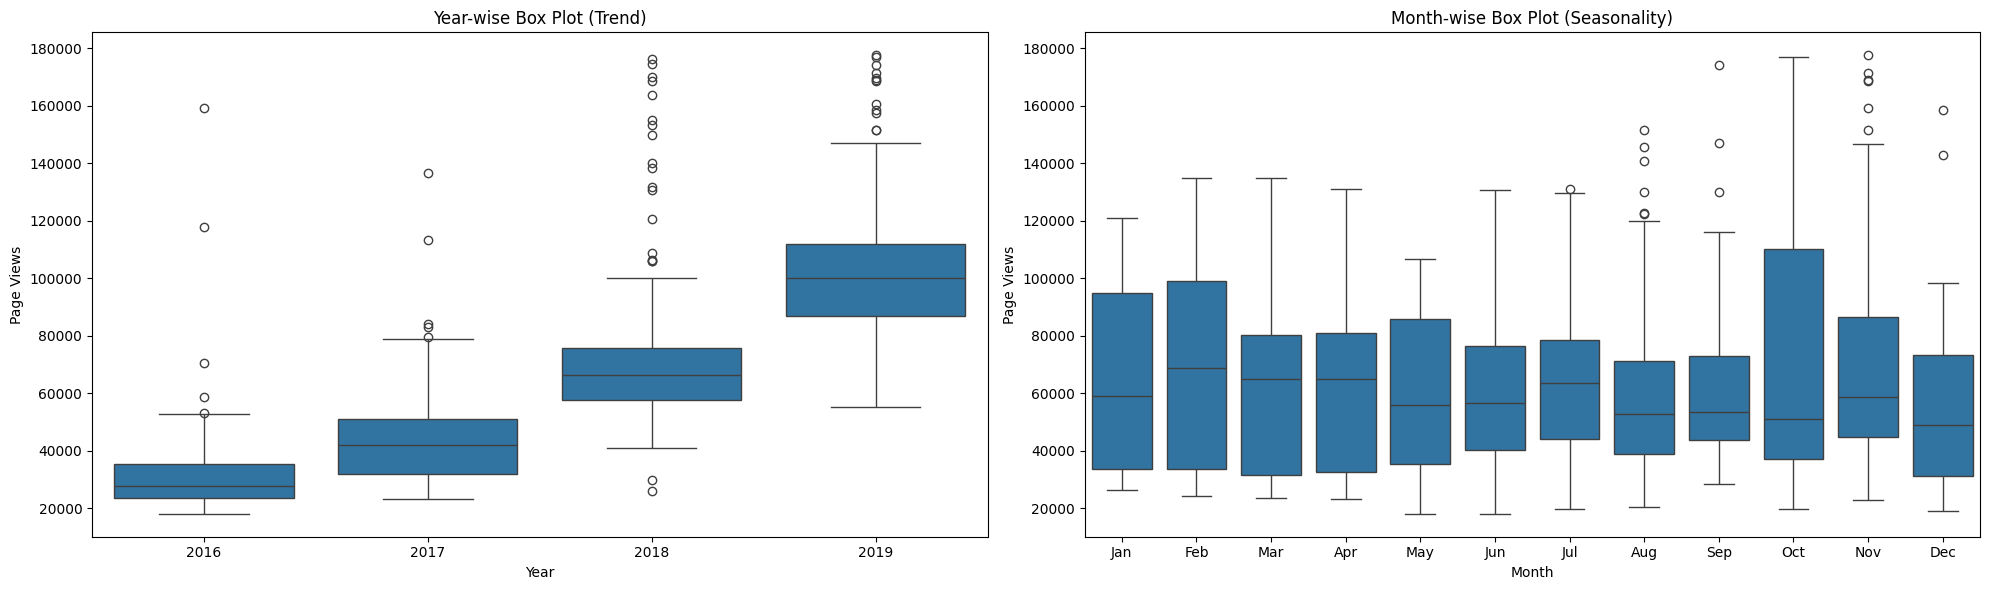

In [4]:
fig1 = draw_line_plot()
plt.show()

fig2 = draw_bar_plot()
plt.show()

fig3 = draw_box_plot()
plt.show()